## Introduction to samplomatic
### Author: Ritajit Majumdar, IBM Quantum
##### (This notebook is consolidated from multiple notebooks prepared by my awesome colleagues who are developing Samplomatic. I am consolidating from all of those to make samplomatic accessible for complete beginners)

This tutorial shows how to use samplomatic for finding probability distribution as well as expectation values. The tutorial focuses primarily on using samplomatic to

- sample from a probability distribution
- post-select the shots to account for non-markovian noise
- perform twirled readout error extinction
- calculate expectation values with and without post selection and readout error mitigation

In the process, it introduces the `Executor` mode of running quantum experiments.

Samplomatic is the latest form of executing a quantum circuit using Qiskit. It is, in particular, useful for performing the state-of-the-art error mitigation techniques such as Propagated Noise Absorption (PNA) and Shaded Lightcone PEC (SLC). Tutorials showing how to perform these mitigations are available <a href="https://github.com/qiskit-community/qdc-challenges-2025/tree/main/day3_tutorials/Track_A">here</a>. This notebook focuses on more basic things and shows how to do simple things such as sampling a probability distribution, calculating expectation values etc. using samplomatic.

To run this notebook you need

- Qiskit 2.0 or later
- Qiskit IBM Runtime 0.45 or later. If that doesn't work, use the `executor-preview` branch of IBM Runtime
- Samplomatic 0.16 or later

### Construct and transpile the circuit

We shall select a simple circuit whose outcome is easy to calculate

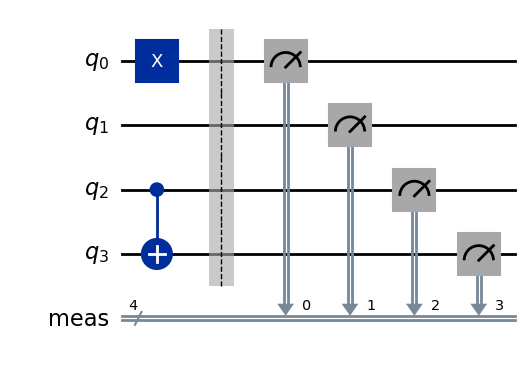

In [1]:
from qiskit.circuit import QuantumCircuit

circuit = QuantumCircuit(4)
circuit.x(0)
circuit.cx(2,3) # essentially does nothing, but I kept it to show gate twirling
circuit.measure_all()
circuit.draw('mpl', style='iqp')

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()
backend = service.backend('ibm_marrakesh')
backend_f = service.backend('ibm_marrakesh', use_fractional_gates=True)

Note that circuits with fractional gates cannot be twirled. So we need to use backend initially to ensure the transpiled circuit does not have fractional gates, and can be twirled. But applying `Rx` pulse for post-selection requires fractional gates. So we initialize the same backend, but now with fractional gates turned on. We shall run the circuit on this backend with fractional gates enabled. Since the coupling map, noise rate etc doesn't change, so nothing changes in this trick.

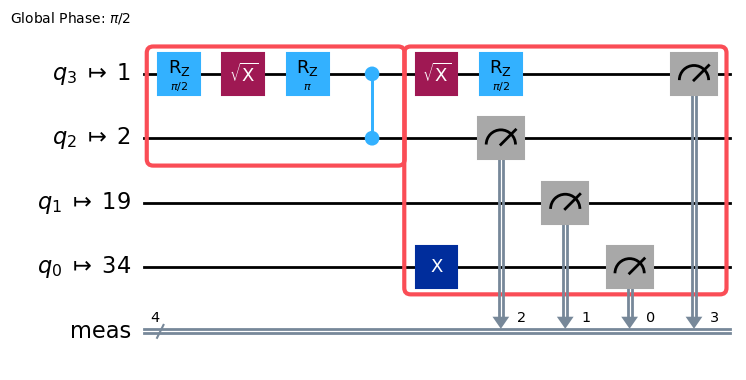

In [3]:
from qiskit.transpiler import generate_preset_pass_manager
from samplomatic.transpiler import generate_boxing_pass_manager

pm = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=42)
pm.post_scheduling = generate_boxing_pass_manager(
    enable_gates=True,
    enable_measures=True,
    twirling_strategy='active'
)

isa_circuit = pm.run(circuit)
isa_circuit.draw('mpl', style='iqp', idle_wires=False)

Here we add the spectator pulse of `Rx` type. The shots are checked on the basis of the action of `Rx` pulse to decide whether they have been contaminated by non-markovian noise or not.

In [4]:
from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.post_selection import PostSelector
from qiskit_addon_utils.noise_management.post_selection.transpiler.passes import AddPostSelectionMeasures, AddSpectatorMeasures

post_selection_pm = PassManager(
    [
        AddSpectatorMeasures(backend_f.coupling_map, add_barrier=True),
        AddPostSelectionMeasures(x_pulse_type="rx"),
    ]
)

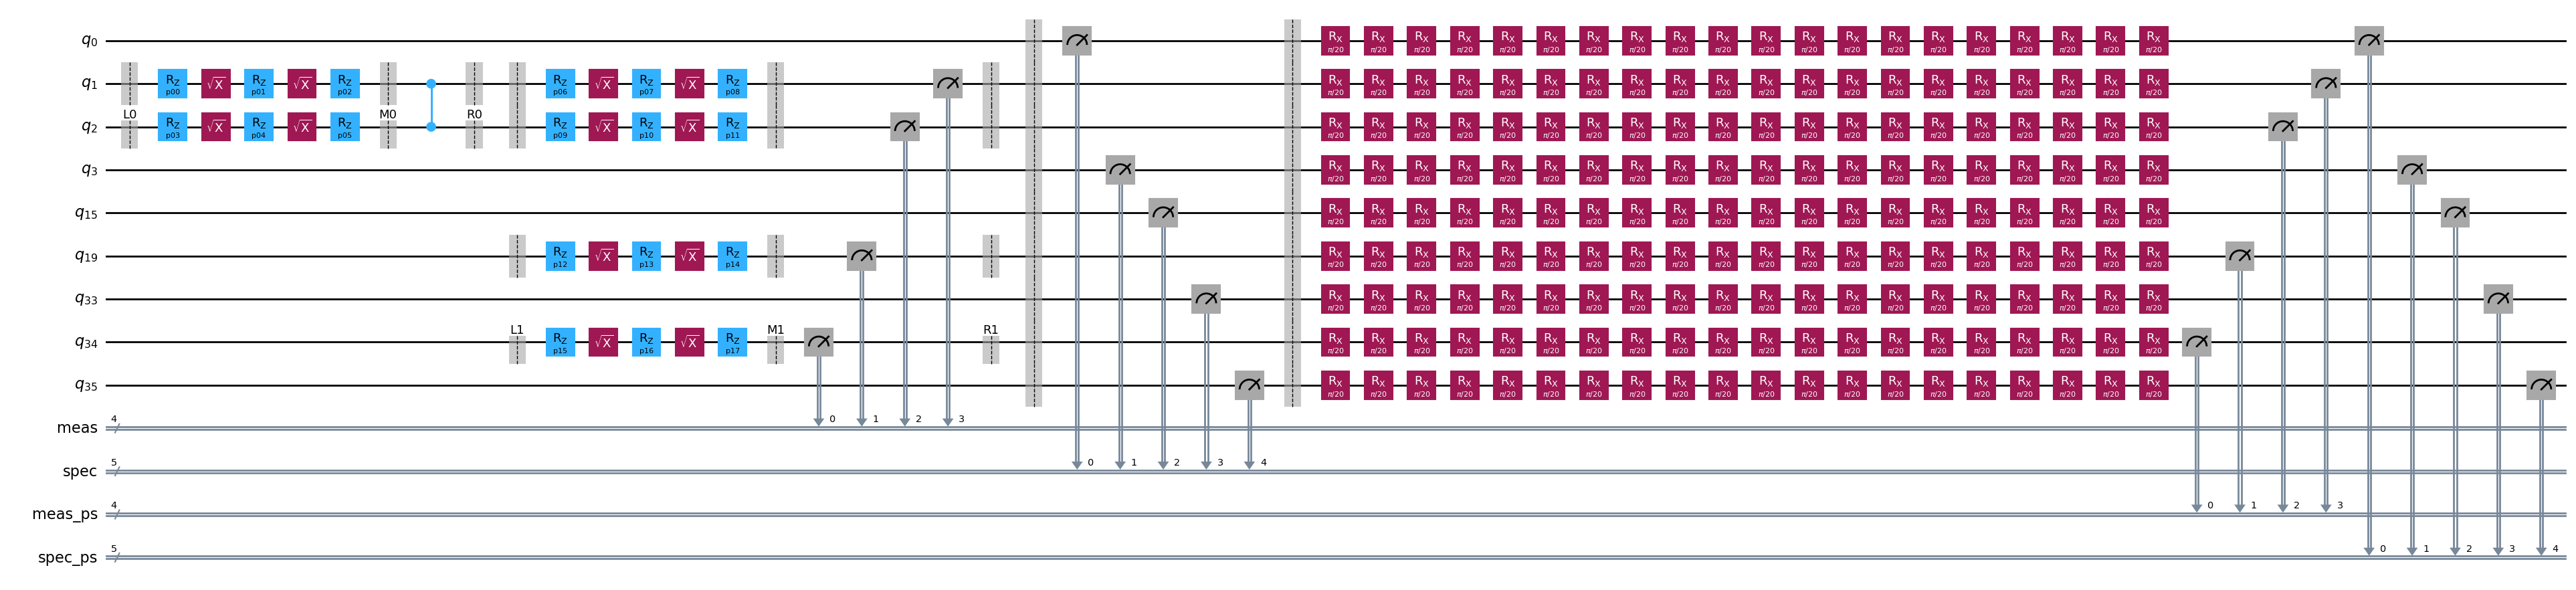

In [5]:
from samplomatic import build

template_circuit, samplex = build(isa_circuit)
template_circuit_ps = post_selection_pm.run(template_circuit)
template_circuit_ps.draw('mpl', fold=-1, idle_wires=False)

Now to execute. We have the liberty of choosing the number of `shots per randomization`. This implies how many shots will be allocated to each twirl instance. Finally, the shape denotes how many such twirls will be used. So `total number of shots = shape[0] * shots per randomization`.

In [6]:
from qiskit_ibm_runtime import QuantumProgram, Executor

shots_per_randomization = 40
shape = 100 # so essentially 4000 shots

program = QuantumProgram(shots=shots_per_randomization)
program.append(
    template_circuit_ps,
    samplex=samplex,
    shape=(shape,)
)

Let us also prepare for `TREX` readout error mitigation. We need to run the calibration circuit for that, which basically runs one circuit, initialized in the state $|0\rangle ^{\otimes n}$. The measurements are twirled to make the average noise model symmetric, and the number of times the measurements deviate from the expected value is noted.

In [7]:
trex_circuit = QuantumCircuit(circuit.num_qubits, circuit.num_qubits)
trex_circuit.measure(range(circuit.num_qubits), range(circuit.num_qubits))

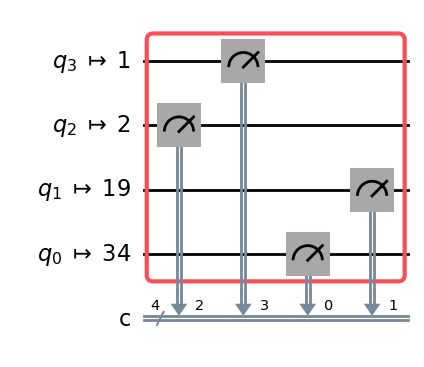

In [8]:
layout = isa_circuit.layout.final_index_layout()
pm_trex = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=42, initial_layout=layout)
pm_trex.post_scheduling = generate_boxing_pass_manager(
    enable_gates=False,
    enable_measures=True,
    twirling_strategy='active'
)
trex_circuit = pm_trex.run(trex_circuit)
trex_circuit.draw('mpl', fold=-1, idle_wires=False)

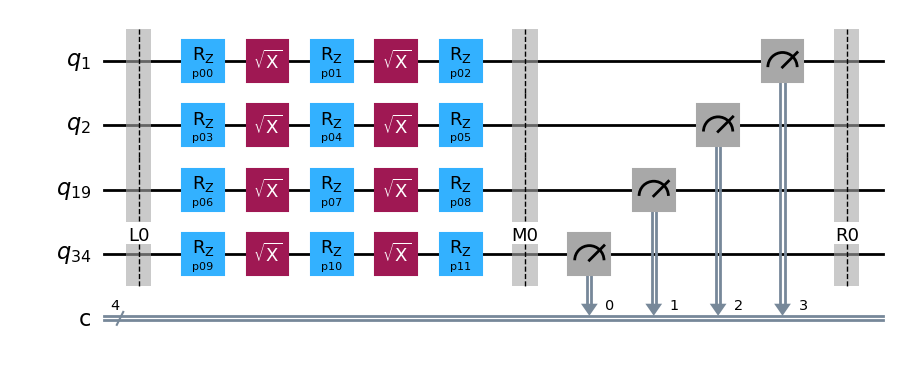

In [9]:
trex_template, trex_samplex = build(trex_circuit)
trex_template.draw('mpl', fold=-1, idle_wires=False)

In [10]:
program.append(trex_template, samplex=trex_samplex, shape=(shape,))
program

QuantumProgram(shots=40, items=[
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x3021119c0>, <Samplex @ 0x1778dd940>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x303376990>, <Samplex @ 0x305379090>, shape=(100,)),
])

As we see now there are two Samplexes in the program, the first is for the original circuit, and the next is for the trex circuit.

In [11]:
executor = Executor(backend_f) # make sure to run on backend with fractional gates enabled
executor_job = executor.run(program)
print(f'Job ID: {executor_job.job_id()}')

Job ID: d6h70khkeb2s73be97gg


We first try to understand the output of this job. Note that there are two jobs in the QuantumProgram, and we collect the two results in individual variables.

In [12]:
executor_result, trex_result = executor_job.result()

`executor_result` is a dictionary. For this example, we have 3 things -- (i) the original measurement outcomes, (ii) the measurement twirling information, and (iii) the outcomes from the spectators for post-selection. Each of them are stored in boolean since `np.bool` requires 1 byte, whereas `int64`, normally used in python, required 8 bytes.

In [13]:
executor_result.keys()

dict_keys(['meas', 'spec', 'meas_ps', 'spec_ps', 'measurement_flips.meas'])

The original measurement outcomes, stored as `meas` (name of the associated classical register) will be array of arrays. There will be 100 cases corresponding to the shape. Each shape will contain 40 trials for each twirl instance, and there are 4 qubits. So the shape will be (100, 40, 4).

In [14]:
import numpy as np
np.shape(executor_result['meas'])

(100, 40, 4)

The measurement twirl information, stored as `measurement_flips.meas` (meas is the name of the associated classical register) will be array of arrays, but one dimension less than `meas`. This contains the twirl information for each twirl instance, i.e., which qubits were flipped for each twirl instance. So while there are 40 shots for each twirl instance, the associated measurement flip is the same for all of them. Hence the shape will be (100,1,4).

In [15]:
np.shape(executor_result['measurement_flips.meas'])

(100, 1, 4)

The post selection adds some pulse to the qubits which are part of the circuit, as well as its nearest neighbours. The layouts used for the circuit is `[1,2,19,34]`. The associated neighbours for these qubits are
- 1 and 2 are neighbours themselves, and their nearest neighbours are 0 and 3
- 15 and 35 and their nearest neighbours of 19
- 33 and 35 are the nearest neighbours of 34

The post selection oriented measurement will act on the nearest neighbour qubits on the layout and their neighbours. So the total number of qubits for post selection, called spectators, are 5 (note that 35 is the nearest neighbour of two qubits in the layout). So the shape of spectator measurement `spec` will be (100, 40, 5).

Let us plot the gate map for a better visualization. The qubits in the layout of the circuit are colored in green, the spectators are colored in purple, and the rest in light blue.

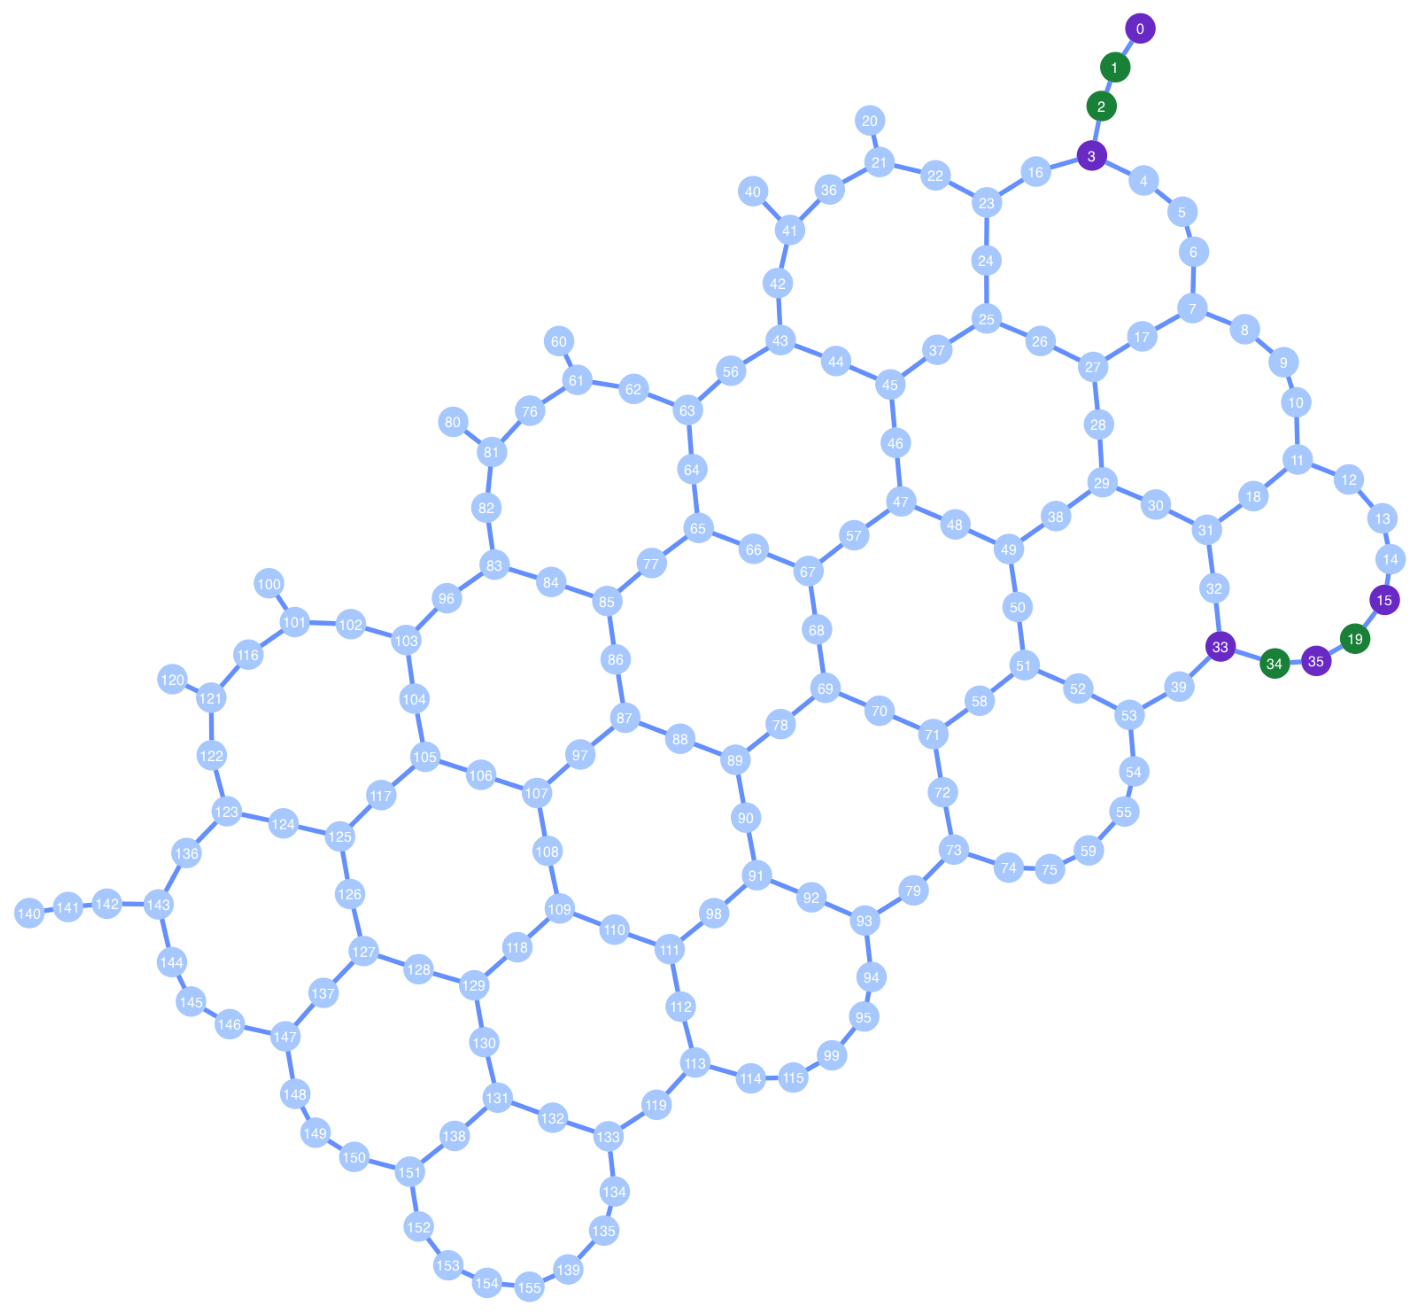

In [16]:
from qiskit.visualization import plot_gate_map
qubit_colors = ['#a6c8ff' for _ in range(backend.num_qubits)]

spectators = [0,3,15,35,33]
for spectator in spectators:
    qubit_colors[spectator] = '#6929c4'

for qubit in isa_circuit.layout.final_index_layout():
    qubit_colors[qubit] = '#198038'

plot_gate_map(backend, qubit_color=qubit_colors)

In [17]:
np.shape(executor_result['spec'])

(100, 40, 5)

Similarly, the qubits are again measured after applying the series of `Rx` pulses. This measurement is again divided into the qubits associated with the circuits and their neighbouring qubits as `meas_ps` and `spec_ps` will be (100,40,4) and (100,40,5) respectively.

In [18]:
print(np.shape(executor_result['meas_ps']))
print(np.shape(executor_result['spec_ps']))

(100, 40, 4)
(100, 40, 5)


Now from this result we can create a `mask`. See the documentation for better understanding of how mask works. In one sentence, the `mask` is a boolen array where each shot is marked as `True` (to be kept) or `False` (to be disarded). There are two strategies, the `node` strategy uses qubit information to decide whether a shot was affected by non-markovian noise, whereas the `edge` strategy uses nearest neighbour connectivity information for the same.

In [19]:
from qiskit_addon_utils.noise_management.post_selection import PostSelector

post_selector = PostSelector.from_circuit(
        circuit=template_circuit_ps, coupling_map=backend.coupling_map
    )

mask_node = post_selector.compute_mask(executor_result, strategy="node")
mask_edge = post_selector.compute_mask(executor_result, strategy="edge")

The mask tells whether a particular shot passed the post selection (True) or not (False). It is not dependent on each qubit outcome for a circuit. Even if one qubit outcome did not pass the post selection, all the 4 qubits for that shot will be discarded. So the mask will be of shape (100, 40).

In [23]:
print(np.shape(mask_node))
print(np.shape(mask_edge))

(100, 40)
(100, 40)


In [20]:
print(f'The node mask for first twirl instance: {mask_node[0]}')
print(f'The edge mask for first twirl instance: {mask_edge[0]}')

The node mask for first twirl instance: [ True  True False  True False  True  True  True  True False  True  True
  True False False False False  True  True  True  True  True  True False
  True False False False False False False False False  True  True False
 False  True  True False]
The edge mask for first twirl instance: [ True  True  True  True  True  True  True  True  True  True  True  True
  True False  True  True False  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False  True  True  True]


The `node` and the `edge` strategy often discards different shots. One can choose to select any of them. Or, in this notebook we shall take a bitwise AND. This, then, becomes a conservative strategy where we retain a shot only if it is passed by both node and edge strategies.

In [21]:
mask = mask_node & mask_edge
print(f'The combined mask for first twirl instance: {mask[0]}')

The combined mask for first twirl instance: [ True  True False  True False  True  True  True  True False  True  True
  True False False False False  True  True  True  True  True  True False
  True False False False False False False False False  True  True False
 False  True  True False]


In [22]:
count_retained = 0

for m in mask:
    count_retained += sum(m)

print(f'Percentage of the shots retained is after post selection {100 * count_retained / (shots_per_randomization*shape)}')

Percentage of the shots retained is after post selection 57.775


Let us now obtain the probability distribution both with and without post selection. 

First we need to account for the measurement twirling, and flip back the bit strings in `meas` to the correct value using the `measurement_flips.c` information. This can be obtained by doing a bitwise XOR. Note that we didn't do the twirling correction for the spectator measurement since those are not twirled.

In [23]:
result_unflipped = executor_result["meas"] ^ executor_result["measurement_flips.meas"]

Now we obtain the probability distribution without post selection.

In [24]:
counts = {}

for val in result_unflipped:
    for result in val:
        count = ''
        for b in result:
            count += str(int(b))
        
        if count in counts:
            counts[count] += 1
        else:
            counts[count] = 1

for key, val in counts.items():
    counts[key] = val/(shots_per_randomization*shape)

In [25]:
counts

{'1000': 0.966,
 '0000': 0.0105,
 '1001': 0.0135,
 '1010': 0.00325,
 '1011': 0.00175,
 '1100': 0.005}

Next we obtain the probability distribution with post selection. Here we follow the same step as before, just ensure that a shot is passed by the mask.

In [26]:
counts_ps = {}

for idx, val in enumerate(result_unflipped):
    for twirl_idx, result in enumerate(val):
        if mask[idx][twirl_idx]:
            count = ''
            for b in result:
                count += str(int(b))
            
            if count in counts_ps:
                counts_ps[count] += 1
            else:
                counts_ps[count] = 1

for key, val in counts_ps.items():
    counts_ps[key] = float(val/count_retained)

In [27]:
counts_ps

{'1000': 0.9749026395499784,
 '1001': 0.0073561228905235825,
 '1010': 0.0021635655560363477,
 '0000': 0.009086975335352661,
 '1011': 0.0021635655560363477,
 '1100': 0.004327131112072695}

We note from the values that post selection somewhat improves upon the result, i.e., the probability of the correct result `1100` is higher when using post selection. This result was extracted from the same quantum experiment, and hence is not due to the statistical difference of multiple executions of the same circuit.

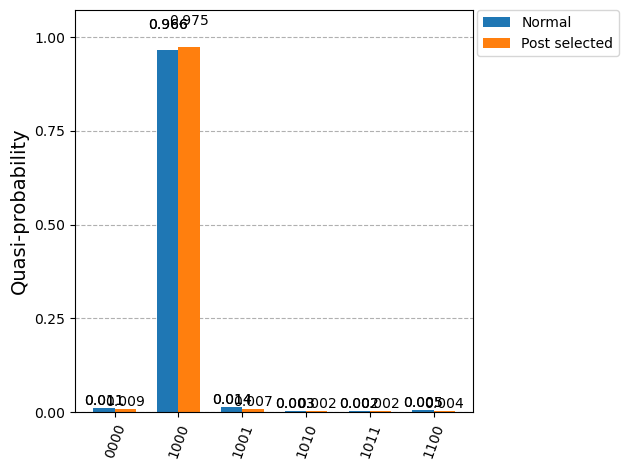

In [28]:
from qiskit.visualization import plot_histogram

plot_histogram([counts, counts_ps], legend=['Normal', 'Post selected'])

We note two important things: 
- the number of shots may not be the same as you defined after post selection. Some shots are discarded, and the number of shots discarded may not be the same for each circuit. So if at any point you need that information (e.g., for calculating the probability distribution), then you should just add up the `items` of the corresponding dictionary to find the retained number of shots for that circuit.

- samplomatic uses an array type storing of data and hence does not use the little endian convention of qiskit.

Next, let us look into the TREX data. For TREX we did not use post selection, although one can choose to. Therefore, the spectator outcomes will not be there in this data. Note that in the TREX circuit, the classical registers were named `c`. So the outcomes of the TREX will be annotated with `c`, not with `meas` as before.

In [29]:
trex_result.keys()

dict_keys(['c', 'measurement_flips.c'])

For measurement error mitigation using TREX, we need to define some observable. Let the observable be $O = \frac{1}{n} \sum_i Z_i$ for this notebook.

In [30]:
from qiskit.quantum_info import SparsePauliOp
observable = SparsePauliOp(['I'*i + 'Z' + 'I'*(circuit.num_qubits - i - 1) for i in range(circuit.num_qubits)],
                            coeffs=[1/circuit.num_qubits]*circuit.num_qubits
                          )
observable

SparsePauliOp(['ZIII', 'IZII', 'IIZI', 'IIIZ'],
              coeffs=[0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j])

First we account for the measurement twirls in trex_result. We can easily obtain the corrected result by taking a bitwise XOR of the observed result (`c`) and the twirl information (`measurement_flips.c`)

In [31]:
trex_corrected = trex_result["c"] ^ trex_result["measurement_flips.c"]
counts_trex = {}

for val in trex_corrected:
    for result in val:
        count = ''
        for b in result:
            count += str(int(b))
        
        if count in counts_trex:
            counts_trex[count] += 1
        else:
            counts_trex[count] = 1

for key, val in counts_trex.items():
    counts_trex[key] = val/(shots_per_randomization*shape)

In [32]:
counts_trex

{'0000': 0.9745,
 '0001': 0.007,
 '0100': 0.00525,
 '1000': 0.008,
 '0010': 0.00475,
 '0011': 0.00025,
 '1010': 0.00025}

Now we can find the expectation value of the observable on the trex counts. We know that this expectation value should be ideally +1. But since the observed data is noisy, there will be some variations, which will provide the measurement error mitigation scaling.

In [33]:
from qiskit.result import sampled_expectation_value
trex_expval = sampled_expectation_value(counts_trex, observable)
trex_expval

0.9870000000000001

Now we can construct the noisy expectation value of the original circuit. Let us construct that both for the raw and the post selected count dictionary.

In [34]:
raw_expval = sampled_expectation_value(counts, observable)
ps_expval = sampled_expectation_value(counts_ps, observable)

Let us perform trex mitigation on both the observables

In [35]:
mitigated_raw_expval = raw_expval / trex_expval
mitigated_ps_expval = ps_expval / trex_expval

The ideal counts of the circuit is known to be `1000`, so we can also calculate the ideal expectation value.

In [39]:
ideal_expval = sampled_expectation_value({'1000': 1.0}, observable)

Now we can compare the ideal expectation value with the observed values for the different cases. Note that this is a really small circuit, and is therefore exposed to a small amount of noise only. However, even here, upon strict scrutiny, one can observe that post selection improves upon the raw expectation value. TREX mitigation on the raw counts is even better than both. Mitigation with post selection is almost of similar performance as mitigation on the raw counts, but that is primarily due to the very small scale of the circuit.

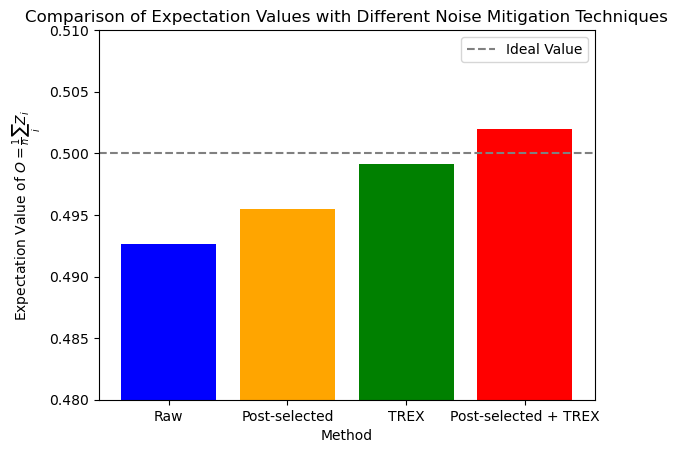

In [43]:
import matplotlib.pyplot as plt

bars = ['Raw', 'Post-selected', 'TREX', 'Post-selected + TREX']
values = [raw_expval, ps_expval, mitigated_raw_expval, mitigated_ps_expval]
plt.bar(bars, values, color=['blue', 'orange', 'green', 'red'])
plt.ylabel(r'Expectation Value of $O = \frac{1}{n} \sum_i Z_i$')
plt.xlabel('Method')
plt.title('Comparison of Expectation Values with Different Noise Mitigation Techniques')
plt.axhline(y=ideal_expval, color='gray', linestyle='--', label='Ideal Value')
plt.ylim(0.48, 0.51)
plt.legend()
plt.show()
